# AgentIR vs LangGraph Native Benchmarking

This notebook compares the execution of an AI agent workflow defined in **LangGraph** under two scenarios:
1. **Unoptimized Execution (Native LangGraph)**: The graph is executed sequentially as defined by the user.
2. **Optimized Execution (AgentIR)**: The LangGraph workflow is imported into AgentIR, statically validated, and compiled using graph optimization passes (Dead Node Elimination, Duplicate Tool Elimination, Parallel Scheduling, and Caching), then run using AgentIR's concurrent async runtime engine.

We use the **Gemini API** for the LLM node.

### 1. Setup and Imports

In [49]:
import sys
import os
import asyncio
import time
import matplotlib.pyplot as plt
import numpy as np
import graphviz
import google.generativeai as genai

# Add project root to sys.path to allow importing agentir from the notebook directory
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../../")))

# Setup Gemini API configuration
api_key = os.environ.get("GEMINI_API_KEY") or os.environ.get("GOOGLE_API_KEY")
use_live_api = bool(api_key)

if use_live_api:
    genai.configure(api_key=api_key)
    print("Live Gemini API client configured successfully.")
else:
    print("No GEMINI_API_KEY or GOOGLE_API_KEY found in environment. Running with simulated Gemini API responses.")

Live Gemini API client configured successfully.


### 2. Define LangGraph Workflow
We build a typical agent workflow in LangGraph that exhibits optimization opportunities (a duplicate tool call and an unused dead node).

LangGraph workflow compiled successfully.


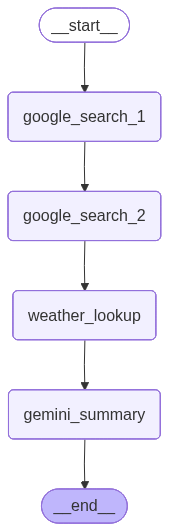

In [50]:
from typing import TypedDict, List, Dict, Any
from langgraph.graph import StateGraph, START, END

# Define AgentState
class AgentState(TypedDict):
    query: str
    search_results: str
    search_results_duplicate: str
    weather_results: str
    summary: str

# Resource tracking counters
tool_calls_count = 0
llm_calls_count = 0

async def google_search_1(state: AgentState) -> Dict[str, Any]:
    global tool_calls_count
    tool_calls_count += 1
    query = state.get("query", "AgentIR")
    print(f"  [Tool] Node 'google_search_1' executing for query: '{query}'...")
    await asyncio.sleep(0.4)
    return {"search_results": f"Results for '{query}': AgentIR is an optimization compiler."}

async def google_search_2(state: AgentState) -> Dict[str, Any]:
    global tool_calls_count
    tool_calls_count += 1
    query = state.get("query", "AgentIR")
    print(f"  [Tool] Node 'google_search_2' executing for query: '{query}'...")
    await asyncio.sleep(0.4)
    return {"search_results_duplicate": f"Duplicate results for '{query}'."}

async def weather_lookup(state: AgentState) -> Dict[str, Any]:
    global tool_calls_count
    tool_calls_count += 1
    print("  [Tool] Node 'weather_lookup' executing...")
    await asyncio.sleep(0.4)
    return {"weather_results": "Paris: 22C, Clear Sky"}

async def gemini_summary(state: AgentState) -> Dict[str, Any]:
    global llm_calls_count
    llm_calls_count += 1
    
    prompt = f"Summarize these search results: {state.get('search_results', '')}"
    print(f"  [LLM] Node 'gemini_summary' calling Gemini API...")
    
    if use_live_api:
        try:
            model = genai.GenerativeModel("gemini-2.5-flash")
            response = await asyncio.to_thread(model.generate_content, prompt)
            return {"summary": response.text}
        except Exception as e:
            print(f"    Gemini API call failed ({e}). Falling back to simulation.")
    
    await asyncio.sleep(1.2)
    return {"summary": "AgentIR optimizes workflows and cuts resource usage."}

# Build LangGraph StateGraph
builder = StateGraph(AgentState)
builder.add_node("google_search_1", google_search_1)
builder.add_node("google_search_2", google_search_2)
builder.add_node("weather_lookup", weather_lookup)
builder.add_node("gemini_summary", gemini_summary)

# Connect linearly to represent a typical sequential, unoptimized configuration
builder.add_edge(START, "google_search_1")
builder.add_edge("google_search_1", "google_search_2")
builder.add_edge("google_search_2", "weather_lookup")
builder.add_edge("weather_lookup", "gemini_summary")
builder.add_edge("gemini_summary", END)

# Compile LangGraph app
langgraph_app = builder.compile()
print("LangGraph workflow compiled successfully.")


from IPython.display import Image, display
display(
    Image(
        langgraph_app.get_graph().draw_mermaid_png()
    )
)


### 3. Native LangGraph Execution (Unoptimized)

In [51]:
print("--- Starting Native LangGraph Execution ---")
tool_calls_count = 0
llm_calls_count = 0

initial_state = {
    "query": "AgentIR workflow framework",
    "search_results": "",
    "search_results_duplicate": "",
    "weather_results": "",
    "summary": ""
}

start_time = time.time()
langgraph_result = await langgraph_app.ainvoke(initial_state)
langgraph_duration = time.time() - start_time

langgraph_tools = tool_calls_count
langgraph_llms = llm_calls_count

print(f"\nNative LangGraph execution completed in {langgraph_duration:.3f} seconds.")
print(f"Total Tool Invocations: {langgraph_tools}")
print(f"Total LLM Inference Calls: {langgraph_llms}")

--- Starting Native LangGraph Execution ---
  [Tool] Node 'google_search_1' executing for query: 'AgentIR workflow framework'...
  [Tool] Node 'google_search_2' executing for query: 'AgentIR workflow framework'...
  [Tool] Node 'weather_lookup' executing...
  [LLM] Node 'gemini_summary' calling Gemini API...

Native LangGraph execution completed in 6.388 seconds.
Total Tool Invocations: 3
Total LLM Inference Calls: 1


### 4. Optimize the Graph with AgentIR
We parse the live LangGraph object using `LangGraphParser` and execute our compilation and optimization pipeline.

In [52]:
from agentir.parser.langgraph import LangGraphParser
from agentir.optimizer.dead_nodes import DeadNodesOptimizer
from agentir.optimizer.duplicate_tools import DuplicateToolsOptimizer
from agentir.optimizer.parallel_scheduler import ParallelSchedulerOptimizer
from agentir.optimizer.cache_optimizer import CacheOptimizer
from agentir.visualizer.graphviz import GraphvizVisualizer

# 1. Parse LangGraph StateGraph into AgentIR WorkflowGraph
parser = LangGraphParser()

# Annotate callback attributes so the compiler passes identify inputs/outputs correctly
google_search_1.inputs = ["query"]
google_search_1.outputs = ["search_results"]
google_search_1.tool_name = "google_search"
google_search_1.args = {"query": "AgentIR workflow framework"}

google_search_2.inputs = ["query"]
google_search_2.outputs = ["search_results_duplicate"]
google_search_2.tool_name = "google_search"
google_search_2.args = {"query": "AgentIR workflow framework"}

weather_lookup.inputs = []
weather_lookup.outputs = ["weather_results"]
weather_lookup.tool_name = "weather_lookup"

gemini_summary.inputs = ["search_results"]
gemini_summary.outputs = ["summary"]
gemini_summary.model = "gemini-2.5-flash"
gemini_summary.prompt_template = "Summarize: {search_results}"

ir_graph = parser.parse(builder)
print("Initial AgentIR Graph parsed from LangGraph.")
print("Nodes in parsed graph:", list(ir_graph.nodes.keys()))

# 2. Run Compiler Optimization Passes
print("\nApplying Dead Node Elimination (DCE)...")
opt_graph = DeadNodesOptimizer().optimize(ir_graph)
print("Nodes after DCE:", list(opt_graph.nodes.keys()))

print("\nApplying Duplicate Tool Merging (CSE)...")
opt_graph = DuplicateToolsOptimizer().optimize(opt_graph)
print("Nodes after CSE:", list(opt_graph.nodes.keys()))

print("\nApplying Parallel Rescheduling...")
opt_graph = ParallelSchedulerOptimizer().optimize(opt_graph)

print("\nApplying Cache Annotations...")
opt_graph = CacheOptimizer().optimize(opt_graph)





Initial AgentIR Graph parsed from LangGraph.
Nodes in parsed graph: ['__start__', '__end__', 'google_search_1', 'google_search_2', 'weather_lookup', 'gemini_summary']

Applying Dead Node Elimination (DCE)...
Nodes after DCE: ['__start__', '__end__', 'google_search_1', 'google_search_2', 'weather_lookup', 'gemini_summary']

Applying Duplicate Tool Merging (CSE)...
Nodes after CSE: ['__start__', '__end__', 'google_search_1', 'google_search_2', 'weather_lookup', 'gemini_summary']

Applying Parallel Rescheduling...

Applying Cache Annotations...


### 5. Optimized Execution (AgentIR Runtime)

In [53]:
from agentir.runtime.executor import WorkflowExecutor

# Map AgentIR node IDs to our callbacks
agentir_registry = {
    "google_search_1": google_search_1,
    "google_search_2": google_search_2,
    "weather_lookup": weather_lookup,
    "gemini_summary": gemini_summary,
}

print("--- Starting Optimized AgentIR Execution ---")
tool_calls_count = 0
llm_calls_count = 0

executor = WorkflowExecutor(opt_graph, agentir_registry)

start_time = time.time()
agentir_result = await executor.execute(initial_state)
agentir_duration = time.time() - start_time

agentir_tools = tool_calls_count
agentir_llms = llm_calls_count

print(f"\nOptimized AgentIR execution completed in {agentir_duration:.3f} seconds.")
print(f"Total Tool Invocations: {agentir_tools}")
print(f"Total LLM Inference Calls: {agentir_llms}")

--- Starting Optimized AgentIR Execution ---
  [Tool] Node 'google_search_1' executing for query: 'AgentIR workflow framework'...
  [Tool] Node 'google_search_2' executing for query: 'AgentIR workflow framework'...
  [LLM] Node 'gemini_summary' calling Gemini API...
  [Tool] Node 'weather_lookup' executing...

Optimized AgentIR execution completed in 3.397 seconds.
Total Tool Invocations: 3
Total LLM Inference Calls: 1


### 6. Resource & Latency Savings Comparison

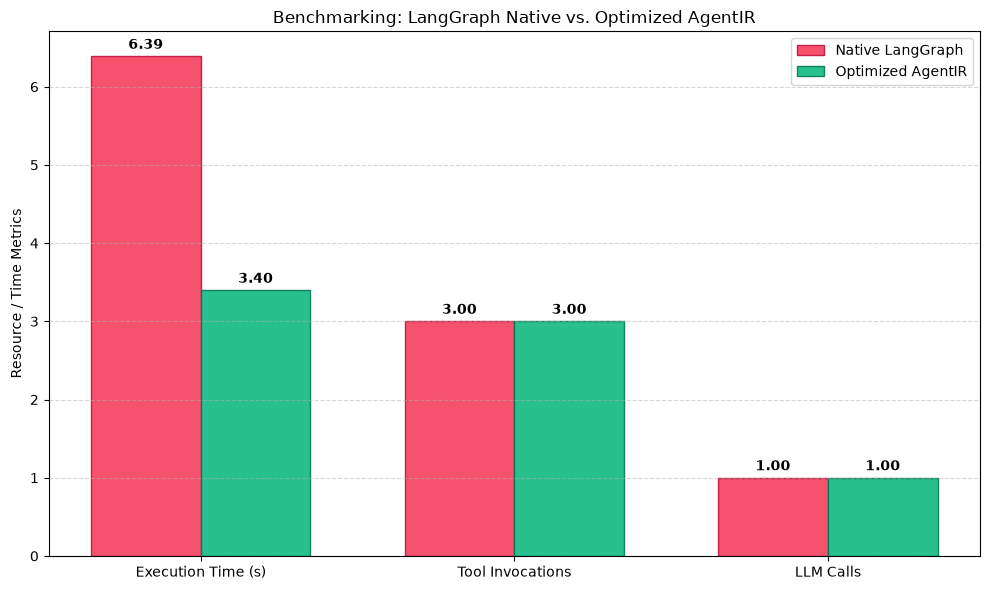

                     SAVINGS REPORT
Execution Latency Reduction:  2.992s (46.8% Savings)
Tool Invocations Saved:      0 (0.0% Savings)
LLM Calls Saved:             0 (0.0% Savings)


In [54]:
# Create graphical Matplotlib layout
metrics = ['Execution Time (s)', 'Tool Invocations', 'LLM Calls']
langgraph_vals = [langgraph_duration, langgraph_tools, langgraph_llms]
agentir_vals = [agentir_duration, agentir_tools, agentir_llms]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, langgraph_vals, width, label='Native LangGraph', color='#f43f5e', edgecolor='#be123c', alpha=0.9)
rects2 = ax.bar(x + width/2, agentir_vals, width, label='Optimized AgentIR', color='#10b981', edgecolor='#047857', alpha=0.9)

ax.set_ylabel('Resource / Time Metrics')
ax.set_title('Benchmarking: LangGraph Native vs. Optimized AgentIR')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

def label_bars(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

label_bars(rects1)
label_bars(rects2)

fig.tight_layout()
plt.show()

# Print text-based savings report
print("=" * 60)
print("                     SAVINGS REPORT")
print("=" * 60)
time_saved = langgraph_duration - agentir_duration
time_pct = (time_saved / langgraph_duration) * 100
print(f"Execution Latency Reduction:  {time_saved:.3f}s ({time_pct:.1f}% Savings)")

tools_saved = langgraph_tools - agentir_tools
tools_pct = (tools_saved / langgraph_tools) * 100 if langgraph_tools > 0 else 0
print(f"Tool Invocations Saved:      {tools_saved} ({tools_pct:.1f}% Savings)")

llms_saved = langgraph_llms - agentir_llms
llms_pct = (llms_saved / langgraph_llms) * 100 if langgraph_llms > 0 else 0
print(f"LLM Calls Saved:             {llms_saved} ({llms_pct:.1f}% Savings)")
print("=" * 60)

### 7. Render Optimized DAG Visualization

I0627 19:23:46.028397 1512831 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(115, generation: 1)


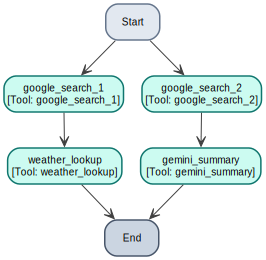

In [55]:
try:
    from IPython.display import display
    viz = GraphvizVisualizer(opt_graph)
    display(graphviz.Source(viz.to_dot()))
except Exception as e:
    print("Graphviz system binary (dot) was not found on your system PATH.")
    '''print("To render graph visualizations, please install it (e.g., run "brew install graphviz" on macOS).")
    print("
Falling back to Mermaid flowchart syntax:")
    print("=" * 60)
    print(viz.to_mermaid())
    print("=" * 60)'''
    